# Title :

---

## Introduction

lorem ipsum

## Methodology

lorem ipsum

### Preprocessing

In [55]:
# Import Library
!pip install xarray
!pip install geopandas
!pip install matplotlib
!pip install netCDF4
!pip install rioxarray
!pip install rasterio
!pip install shapely
!pip install rasterstats
!pip install elevation


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━

In [56]:
import xarray as xr
import rioxarray
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio import features
from shapely.geometry import Point
from rasterstats import zonal_stats
import elevation


In [46]:
# Open dataset
df = xr.open_dataset("temp_data_SRS.nc", engine="netcdf4") # lazy loading, tmp files
usa = gpd.read_file("cb_2018_us_state_500k.zip").to_crs(epsg=4326) # uk boundaries shp
usa = usa[~usa["STUSPS"].isin(["AK", "HI", "PR", "AS", "VI", "GU", "MP"])] # remove non us states/territories
usa = usa.dissolve() # dissolve to single polygon

minx, miny, maxx, maxy = usa.total_bounds
print("Lon:", minx, maxx, "Lat:", miny, maxy)
geom = usa.geometry.iloc[0]

pad = 0.1 # add some padding around the polygon to make sure we get all of it (and a bit of sea around)
minx1, maxx1 = minx - pad, maxx + pad
miny1, maxy1 = miny - pad, maxy + pad

df_usa = df.sel(lon=slice(minx1, maxx1), lat=slice(miny1, maxy1))
print(df_usa)

Lon: -124.763068 -66.949895 Lat: 24.523096 49.384358
<xarray.Dataset> Size: 62MB
Dimensions:  (time: 1344, lat: 50, lon: 116)
Coordinates:
  * time     (time) datetime64[ns] 11kB 1901-01-16 1901-02-15 ... 2012-12-16
  * lat      (lat) float64 400B 24.75 25.25 25.75 26.25 ... 48.25 48.75 49.25
  * lon      (lon) float64 928B -124.8 -124.2 -123.8 ... -68.25 -67.75 -67.25
Data variables:
    tmp      (time, lat, lon) float64 62MB ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS3.21 Mean Temperature
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 1307101324\nData generated by BADC from:\ntmp.1307...
    history:      Wed 10 Jul 2013 17:04:15 BST : User ianharris : Program mak...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Data restrictions: for academic research use only.Contact B...
    contact:      BADC <badc@rl.ac.uk>


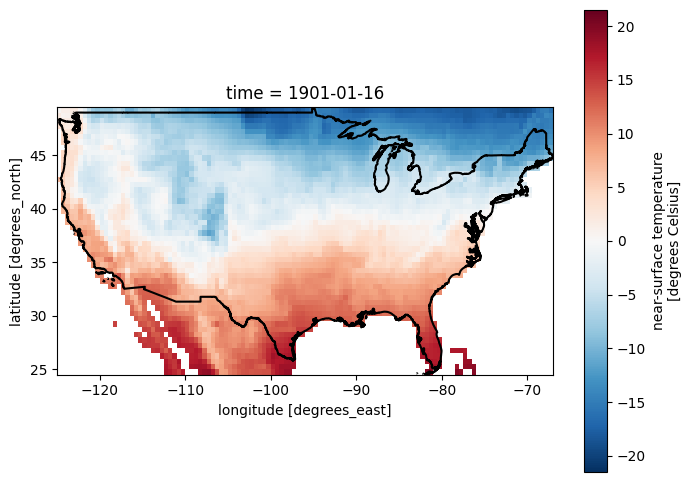

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

df_usa.tmp.isel(time=0).plot(ax=ax)

usa.boundary.plot(ax=ax, color="black")

plt.show()

In [48]:
transform = df_usa.rio.transform()
out_shape = (len(df_usa.lat), len(df_usa.lon))


In [49]:
df_usa = df_usa.sortby("lat")  # ensure lat ascending

df_usa = df_usa.rio.set_spatial_dims(
    x_dim="lon",
    y_dim="lat",
    inplace=False
)

# Ensure CRS
df_usa = df_usa.rio.write_crs("EPSG:4326")
print(df_usa)
# Clip using polygon with intersection logic
df_usa = df_usa.rio.clip(
    usa.geometry,
    usa.crs,
    all_touched=True,   # 🔥 critical
    drop=True
)

<xarray.Dataset> Size: 62MB
Dimensions:      (time: 1344, lat: 50, lon: 116)
Coordinates:
  * time         (time) datetime64[ns] 11kB 1901-01-16 1901-02-15 ... 2012-12-16
  * lat          (lat) float64 400B 24.75 25.25 25.75 ... 48.25 48.75 49.25
  * lon          (lon) float64 928B -124.8 -124.2 -123.8 ... -67.75 -67.25
    spatial_ref  int64 8B 0
Data variables:
    tmp          (time, lat, lon) float64 62MB ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS3.21 Mean Temperature
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 1307101324\nData generated by BADC from:\ntmp.1307...
    history:      Wed 10 Jul 2013 17:04:15 BST : User ianharris : Program mak...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Data restrictions: for academic research use only.Contact B...
    contact:      BADC <badc@rl.ac.uk>


<Axes: title={'center': 'time = 1917-09-16, spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

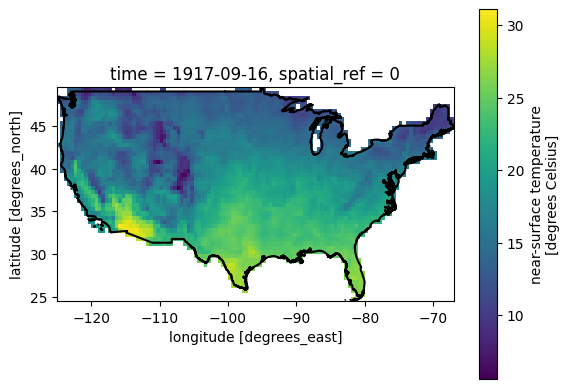

In [75]:
df_usa.tmp.isel(time=200).plot()
usa.boundary.plot(ax=plt.gca(), color="black")

In [51]:
# Step 1: Make 2D mesh of coordinates
lon2d, lat2d = np.meshgrid(df_usa.lon.values, df_usa.lat.values)
lon_flat = lon2d.ravel()
lat_flat = lat2d.ravel()

# Step 2: Vectorized GeoDataFrame
pts = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lon_flat, lat_flat),
    crs="EPSG:4326"
).to_crs("EPSG:3857")  # meters

# Step 3: Load coastline once
coast = gpd.read_file("https://naciscdn.org/naturalearth/50m/physical/ne_50m_coastline.zip")
coast = coast.cx[-130:-60, 15:60].to_crs("EPSG:3857")
coast_union = coast.unary_union

# Step 4: Vectorized distance calculation
pts["dist_coast_m"] = pts.distance(coast_union)

# Step 5: Reshape back to grid
dist_coast_grid = pts["dist_coast_m"].values.reshape(lon2d.shape)

/tmp/ipykernel_3370/1561776515.py:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  coast_union = coast.unary_union


In [ ]:
df_usa["distance_to_coast"] = (("lat", "lon"), dist_coast_grid / 1000)  # km

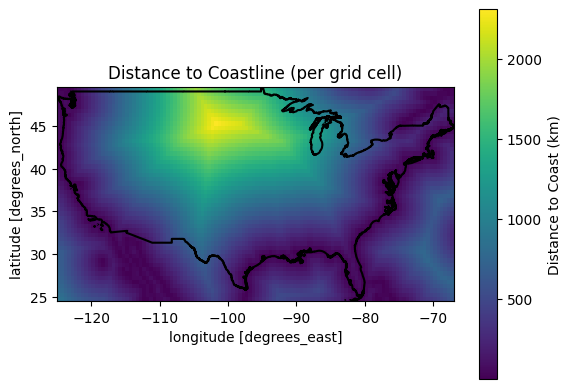

In [ ]:
# Plot distance to coast (choose one “time” slice if needed, but it's 2D)
df_usa.distance_to_coast.plot(
    cmap="viridis",  # or "magma", "plasma", etc.
    cbar_kwargs={"label": "Distance to Coast (km)"}
)

# Overlay US boundaries
usa.boundary.plot(ax=plt.gca(), color="black")

plt.title("Distance to Coastline (per grid cell)")
plt.show()

In [71]:
df_usa.to_netcdf(
    "us_temp.nc",
    format="NETCDF4"
)